In [1]:
import pandas as pd

train_df = pd.read_csv("../data/rus_news_data/train.csv")

train_df.head()

,Unnamed: 0,text,rubric
0,3102,В Северной Осетии на создание дополнительных м...,Нацпроекты
1,495,Двукратный олимпийский чемпион Евгений Плющен...,Спорт
2,4100,Обезьяна бросилась на жительницу индийского ок...,Из жизни
3,2292,Пользователи Twitter поспорили о реакции интер...,Интернет и СМИ
4,3365,Россиянка по имени Юлия на днях вернулась из И...,Россия


In [4]:
train_df["rubric"].value_counts()

rubric
Россия               635
Мир                  502
Спорт                346
Экономика            294
Бывший СССР          276
Силовые структуры    154
Интернет и СМИ       148
Наука и техника      146
Культура             144
Из жизни             138
Путешествия          128
Ценности              99
Дом                   86
Нацпроекты            37
69-я параллель        19
Name: count, dtype: int64

In [4]:
train_df.columns

Index(['Unnamed: 0', 'text', 'rubric'], dtype='str')

In [6]:
train_df["rubric"].value_counts()

rubric
Россия               635
Мир                  502
Спорт                346
Экономика            294
Бывший СССР          276
Силовые структуры    154
Интернет и СМИ       148
Наука и техника      146
Культура             144
Из жизни             138
Путешествия          128
Ценности              99
Дом                   86
Нацпроекты            37
69-я параллель        19
Name: count, dtype: int64

In [7]:
train_df["text"].str.split().str.len().describe()

count    3152.000000
mean      184.371827
std       160.014043
min        44.000000
25%       131.000000
50%       162.000000
75%       201.000000
max      3857.000000
Name: text, dtype: float64

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
print(os.getcwd())

/Users/ichabod/news-classification


In [4]:
import hydra
from hydra import compose, initialize
from hydra.core.global_hydra import GlobalHydra

from models.lstm import LSTMClassifier
from scripts.modules.data_module import NewsDataModule

GlobalHydra.instance().clear()

initialize(version_base=None, config_path="../config")
cfg = compose(config_name="config")

dm = NewsDataModule(cfg)
dm.setup()

model = LSTMClassifier.load_from_checkpoint(
    "./1/dfcfc83fa0e94ba4bcda10faed51b90d/checkpoints/epoch=14-step=750.ckpt",
    class_weights=dm.class_weights,
)

model.eval();

In [5]:
import torch

y_true = []
y_pred = []

loader = dm.test_dataloader()

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)

with torch.no_grad():
    for x, y in loader:
        x = x.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1).cpu()

        y_pred.extend(preds.numpy())
        y_true.extend(y.numpy())

In [6]:
from sklearn.metrics import classification_report

target_names = [dm.idx2label[i] for i in range(dm.num_classes)]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=3,
    )
)

                   precision    recall  f1-score   support

   69-я параллель      0.000     0.000     0.000         4
      Бывший СССР      0.769     0.678     0.721        59
              Дом      0.231     0.316     0.267        19
         Из жизни      0.360     0.621     0.456        29
   Интернет и СМИ      0.122     0.290     0.171        31
         Культура      0.298     0.548     0.386        31
              Мир      0.612     0.481     0.539       108
  Наука и техника      0.524     0.355     0.423        31
       Нацпроекты      1.000     0.875     0.933         8
      Путешествия      0.278     0.357     0.312        28
           Россия      0.579     0.537     0.557       136
Силовые структуры      0.762     0.485     0.593        33
            Спорт      0.932     0.743     0.827        74
         Ценности      0.714     0.476     0.571        21
        Экономика      0.689     0.492     0.574        63

         accuracy                          0.526      

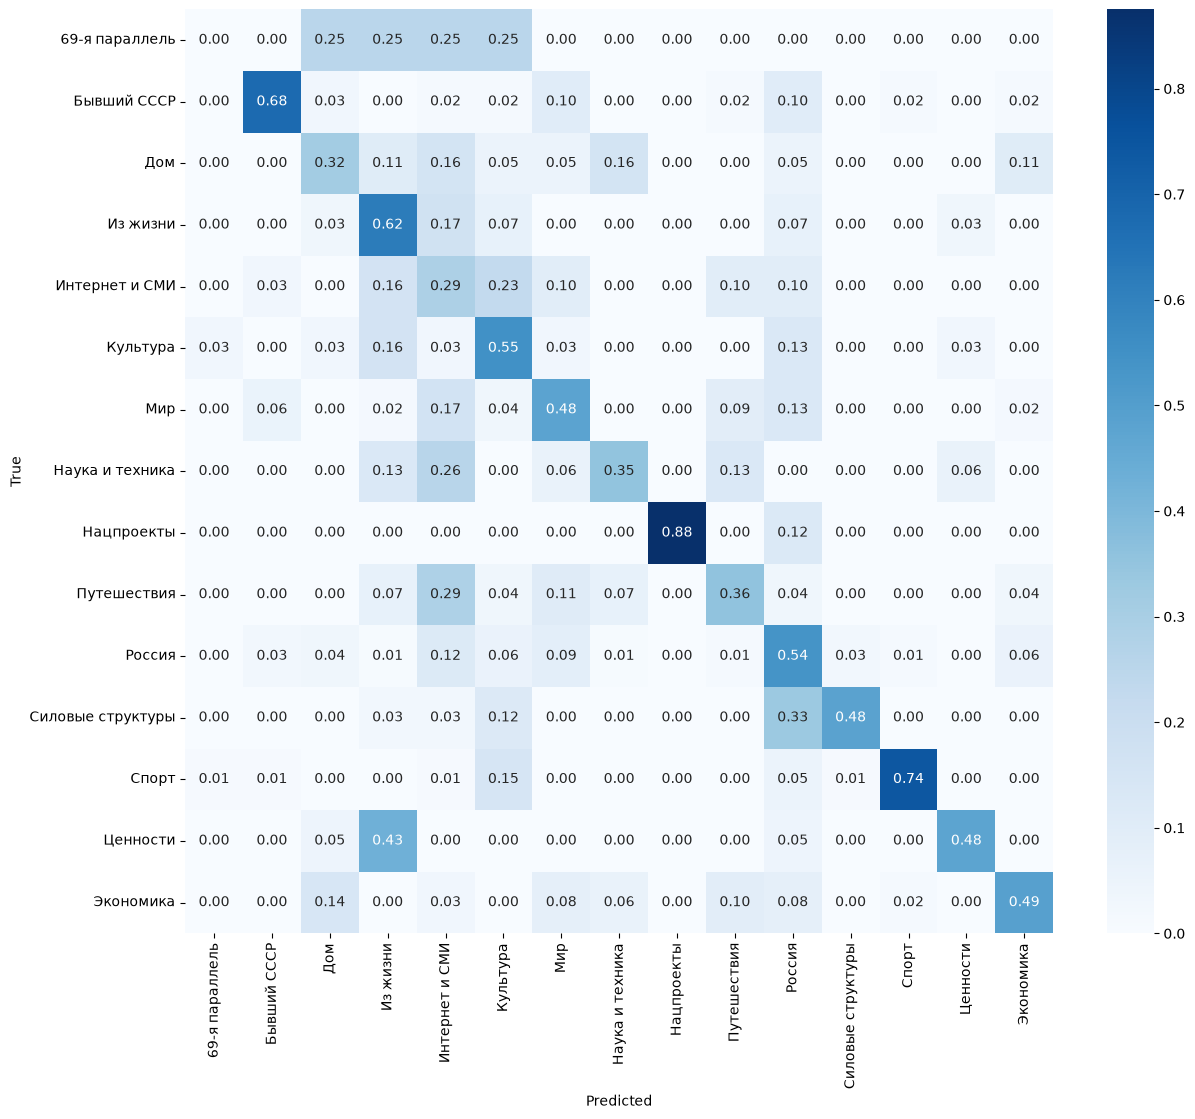

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues",
    ax=ax,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
print(checkpoint_path)

NameError: name 'checkpoint_path' is not defined

In [2]:
import json

import torch
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader

os.chdir(Path.cwd().parent)

import os
from pathlib import Path

import pandas as pd

from models.lstm import LSTMClassifier
from scripts.modules.dataset import NewsDataset
from scripts.modules.preprocess import preprocessing

with open("artifacts/label2idx.json") as f:
    label2idx = json.load(f)

with open("artifacts/word2idx.json") as f:
    word2idx = json.load(f)

idx2label = {int(v): k for k, v in label2idx.items()}

model = LSTMClassifier.load_from_checkpoint(
    "./1/dfcfc83fa0e94ba4bcda10faed51b90d/checkpoints/epoch=14-step=750.ckpt"
)

model.eval()

df = pd.read_csv("data/rus_news_data/test.csv")
df["text"] = df["text"].apply(preprocessing)
df["label"] = df["rubric"].map(label2idx)

dataset = NewsDataset(df, word2idx, max_length=256)
loader = DataLoader(dataset, batch_size=32)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in loader:
        x = x.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1).cpu()

        y_pred.extend(preds.numpy())
        y_true.extend(y.numpy())

target_names = [idx2label[i] for i in range(len(idx2label))]

print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

ModuleNotFoundError: No module named 'models'

In [37]:
ckpt = torch.load(
    "./1/dfcfc83fa0e94ba4bcda10faed51b90d/checkpoints/epoch=14-step=750.ckpt"
)
print(ckpt["hyper_parameters"])

{'vocab_size': 33412, 'num_classes': 15, 'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.001}


In [33]:
print(label2idx)
print(idx2label)
print(len(label2idx))

{'69-я параллель': 0, 'Бывший СССР': 1, 'Дом': 2, 'Из жизни': 3, 'Интернет и СМИ': 4, 'Культура': 5, 'Мир': 6, 'Наука и техника': 7, 'Нацпроекты': 8, 'Путешествия': 9, 'Россия': 10, 'Силовые структуры': 11, 'Спорт': 12, 'Ценности': 13, 'Экономика': 14}
{0: '69-я параллель', 1: 'Бывший СССР', 2: 'Дом', 3: 'Из жизни', 4: 'Интернет и СМИ', 5: 'Культура', 6: 'Мир', 7: 'Наука и техника', 8: 'Нацпроекты', 9: 'Путешествия', 10: 'Россия', 11: 'Силовые структуры', 12: 'Спорт', 13: 'Ценности', 14: 'Экономика'}
15


In [35]:
ckpt = torch.load(
    "./1/6f235d71bc7e41239780f88f1032578a/checkpoints/epoch=14-step=750.ckpt"
)
print(ckpt["hyper_parameters"]["num_classes"])

15


In [39]:
print(model.hparams)

"embed_dim":   128
"hidden_dim":  256
"lr":          0.001
"num_classes": 15
"vocab_size":  33412


In [40]:
print(model)

LSTMClassifier(
  (embedding): Embedding(33412, 128)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=15, bias=True)
  (loss_fn): CrossEntropyLoss()
  (f1): MulticlassF1Score()
  (acc): MulticlassAccuracy()
)


In [41]:
import numpy as np

pred_classes, pred_counts = np.unique(y_pred, return_counts=True)

for cls, cnt in zip(pred_classes, pred_counts):
    print(cls, idx2label[cls], cnt)

1 Бывший СССР 9
2 Дом 3
3 Из жизни 187
4 Интернет и СМИ 36
5 Культура 4
6 Мир 5
7 Наука и техника 107
8 Нацпроекты 1
9 Путешествия 4
10 Россия 5
11 Силовые структуры 190
12 Спорт 47
13 Ценности 68
14 Экономика 9


In [42]:
x, y = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    logits = model(x)

print(logits[:5])

tensor([[ 0.0171,  0.2922, -0.1667,  0.6501,  0.4392,  0.0019, -0.4118,  0.3299,
         -0.6133, -0.0533, -0.0023,  0.5795,  0.0902,  0.1237, -0.1216],
        [-0.1419,  0.2787, -0.0211,  0.1107,  0.5123, -0.0676, -0.1140,  0.0544,
         -0.4088,  0.1210,  0.2468,  0.4605,  0.1212,  0.1482,  0.1661],
        [ 0.0819,  0.0419,  0.0231,  0.0887,  0.1730, -0.1931, -0.2766,  0.1845,
         -0.0020, -0.0109,  0.1073,  0.2271,  0.1168,  0.2995,  0.2546],
        [ 0.1013,  0.1777, -0.1632,  0.4326,  0.2426, -0.0135, -0.1720,  0.3884,
         -0.1423, -0.2193,  0.0145,  0.2404, -0.0698,  0.3940, -0.1181],
        [-0.0928,  0.2434, -0.2914,  0.2341, -0.0055, -0.2474,  0.1225,  0.4058,
          0.0636, -0.1901,  0.2530,  0.3289,  0.2584,  0.3083,  0.1097]],
       device='mps:0')


In [44]:
print(model.hparams)
print(model.lstm.num_layers)
print()
print(hasattr(model, "attention_gate"))
print(hasattr(model, "attention"))

"embed_dim":   128
"hidden_dim":  256
"lr":          0.001
"num_classes": 15
"vocab_size":  33412
1

False
False


In [45]:
ckpt = torch.load(
    "./1/dfcfc83fa0e94ba4bcda10faed51b90d/checkpoints/epoch=14-step=750.ckpt",
    map_location="cpu",
)

print(ckpt["hyper_parameters"])

{'vocab_size': 33412, 'num_classes': 15, 'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.001}


In [46]:
print(list(ckpt["state_dict"].keys())[:30])

['embedding.weight', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l0_reverse', 'lstm.weight_hh_l0_reverse', 'lstm.bias_ih_l0_reverse', 'lstm.bias_hh_l0_reverse', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'lstm.weight_ih_l1_reverse', 'lstm.weight_hh_l1_reverse', 'lstm.bias_ih_l1_reverse', 'lstm.bias_hh_l1_reverse', 'lstm.weight_ih_l2', 'lstm.weight_hh_l2', 'lstm.bias_ih_l2', 'lstm.bias_hh_l2', 'lstm.weight_ih_l2_reverse', 'lstm.weight_hh_l2_reverse', 'lstm.bias_ih_l2_reverse', 'lstm.bias_hh_l2_reverse', 'attention_gate.weight', 'attention_gate.bias', 'fc.weight', 'fc.bias', 'loss_fn.weight']


In [47]:
import models.lstm
from models.lstm import LSTMClassifier

print(models.lstm.__file__)

/Users/ichabod/news-classification/models/lstm.py


In [48]:
import inspect

print(inspect.signature(LSTMClassifier.__init__))

(self, vocab_size, num_classes, embed_dim=128, hidden_dim=256, lr=0.001)
